**Project Title**
Wildfire Detection using Artificial Intelligence and Machine Learning

**Problem Statement**
Wildfires cause massive destruction to forests, wildlife and human settlements and traditional detection methods are often slow and ineffective. There is a need for an intelligent system that can detect wildfires at an early stage with high accuracy.

**Description**
This project aims to build an AI-based wildfire detection system that analyzes environmental or satellite data to identify fire outbreaks in real-time. Using machine learning and image processing techniques, the system can provide early alerts to help prevent large-scale damage.

In [1]:
##import libraries
import os
import pandas as pd
import numpy as np

##Plotting
import matplotlib.pyplot as plt
import seaborn as sns

##Preprocessing
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

##Saving models
import joblib

##Dataset Loaded
df = pd.read_csv("Dataset_Final.csv")
print("Original dataset shape:", df.shape)
df.head(50)

Original dataset shape: (78425, 15)


,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,9.3280,77.6247,318.0,1.1,1.0,2023-01-01,821,Aqua,MODIS,62,61.03,305.0,7.6,D,0
1,10.4797,77.9378,313.8,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,299.4,4.3,D,0
2,13.2478,77.2639,314.7,1.0,1.0,2023-01-01,822,Aqua,MODIS,55,61.03,302.4,4.9,D,0
3,12.2994,78.4085,314.3,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,301.9,4.8,D,0
4,14.1723,75.5024,338.4,1.2,1.1,2023-01-01,823,Aqua,MODIS,88,61.03,305.3,41.5,D,0
5,14.1707,75.4922,322.2,1.2,1.1,2023-01-01,823,Aqua,MODIS,66,61.03,301.7,16.0,D,0
6,15.1699,76.6700,319.2,1.0,1.0,2023-01-01,823,Aqua,MODIS,22,61.03,305.3,6.7,D,2
7,14.9327,75.1098,317.1,1.2,1.1,2023-01-01,823,Aqua,MODIS,38,61.03,302.4,9.6,D,0
8,15.2106,76.6382,320.4,1.0,1.0,2023-01-01,823,Aqua,MODIS,60,61.03,305.8,9.6,D,0
9,16.1519,80.6908,319.1,1.3,1.1,2023-01-01,823,Aqua,MODIS,30,61.03,300.9,12.6,D,0


In [2]:
##Remove rows of misisng vlues
df = df.dropna()

In [3]:
df

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,9.3280,77.6247,318.0,1.1,1.0,2023-01-01,821,Aqua,MODIS,62,61.03,305.0,7.6,D,0
1,10.4797,77.9378,313.8,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,299.4,4.3,D,0
2,13.2478,77.2639,314.7,1.0,1.0,2023-01-01,822,Aqua,MODIS,55,61.03,302.4,4.9,D,0
3,12.2994,78.4085,314.3,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,301.9,4.8,D,0
4,14.1723,75.5024,338.4,1.2,1.1,2023-01-01,823,Aqua,MODIS,88,61.03,305.3,41.5,D,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78420,17.1067,74.4049,304.0,2.3,1.5,2023-12-31,1715,Terra,MODIS,58,61.03,289.2,23.2,N,0
78421,16.3284,75.2590,304.2,2.6,1.5,2023-12-31,1715,Terra,MODIS,59,61.03,288.9,29.5,N,0
78422,21.1095,72.6422,306.5,1.9,1.3,2023-12-31,1716,Terra,MODIS,68,61.03,294.2,18.2,N,2
78423,21.0664,72.8734,310.0,1.0,1.0,2023-12-31,2125,Aqua,MODIS,79,61.03,292.7,10.2,N,2


In [4]:
##Remove duplicates
df=df.drop_duplicates()

In [5]:
df

,latitude,longitude,brightness,scan,track,acq_date,acq_time,satellite,instrument,confidence,version,bright_t31,frp,daynight,type
0,9.3280,77.6247,318.0,1.1,1.0,2023-01-01,821,Aqua,MODIS,62,61.03,305.0,7.6,D,0
1,10.4797,77.9378,313.8,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,299.4,4.3,D,0
2,13.2478,77.2639,314.7,1.0,1.0,2023-01-01,822,Aqua,MODIS,55,61.03,302.4,4.9,D,0
3,12.2994,78.4085,314.3,1.0,1.0,2023-01-01,822,Aqua,MODIS,58,61.03,301.9,4.8,D,0
4,14.1723,75.5024,338.4,1.2,1.1,2023-01-01,823,Aqua,MODIS,88,61.03,305.3,41.5,D,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78420,17.1067,74.4049,304.0,2.3,1.5,2023-12-31,1715,Terra,MODIS,58,61.03,289.2,23.2,N,0
78421,16.3284,75.2590,304.2,2.6,1.5,2023-12-31,1715,Terra,MODIS,59,61.03,288.9,29.5,N,0
78422,21.1095,72.6422,306.5,1.9,1.3,2023-12-31,1716,Terra,MODIS,68,61.03,294.2,18.2,N,2
78423,21.0664,72.8734,310.0,1.0,1.0,2023-12-31,2125,Aqua,MODIS,79,61.03,292.7,10.2,N,2


In [6]:
print(df.head(500))

     latitude  longitude  brightness  scan  track    acq_date  acq_time  \
0      9.3280    77.6247       318.0   1.1    1.0  2023-01-01       821   
1     10.4797    77.9378       313.8   1.0    1.0  2023-01-01       822   
2     13.2478    77.2639       314.7   1.0    1.0  2023-01-01       822   
3     12.2994    78.4085       314.3   1.0    1.0  2023-01-01       822   
4     14.1723    75.5024       338.4   1.2    1.1  2023-01-01       823   
..        ...        ...         ...   ...    ...         ...       ...   
495   17.5890    75.4252       301.9   1.1    1.0  2023-01-04      1651   
496   17.5874    75.4150       300.5   1.1    1.0  2023-01-04      1651   
497   17.6594    75.4702       307.4   1.1    1.0  2023-01-04      1651   
498   17.7676    75.2187       300.8   1.1    1.1  2023-01-04      1651   
499   17.9780    75.0095       300.4   1.1    1.1  2023-01-04      1651   

    satellite instrument  confidence  version  bright_t31   frp daynight  type  
0        Aqua     

In [7]:
##clean Data is copied
df.to_csv("Copied_dataset.csv",index=False)
print("Dataset copied successfully to copied_dataset.csv")

Dataset copied successfully to copied_dataset.csv


In [8]:
##Explore Data
print(df.info())
print(df.describe())
print(df.columns)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 78425 entries, 0 to 78424
Data columns (total 15 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   latitude    78425 non-null  float64
 1   longitude   78425 non-null  float64
 2   brightness  78425 non-null  float64
 3   scan        78425 non-null  float64
 4   track       78425 non-null  float64
 5   acq_date    78425 non-null  object 
 6   acq_time    78425 non-null  int64  
 7   satellite   78425 non-null  object 
 8   instrument  78425 non-null  object 
 9   confidence  78425 non-null  int64  
 10  version     78425 non-null  float64
 11  bright_t31  78425 non-null  float64
 12  frp         78425 non-null  float64
 13  daynight    78425 non-null  object 
 14  type        78425 non-null  int64  
dtypes: float64(8), int64(3), object(4)
memory usage: 9.0+ MB
None
           latitude     longitude    brightness          scan         track  \
count  78425.000000  78425.000000  78425.000000 

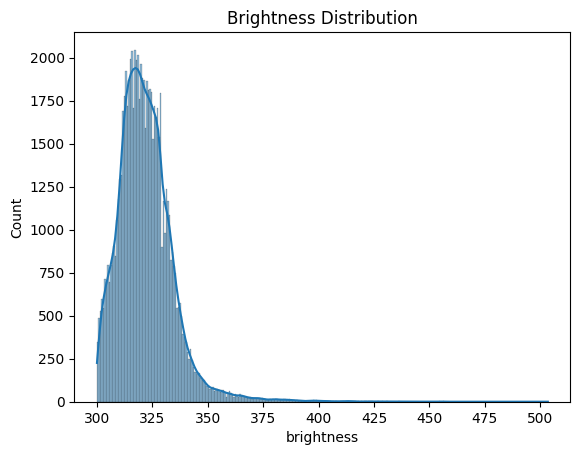

In [9]:
##Visualization
sns.histplot(df["brightness"], kde=True)
plt.title("Brightness Distribution")
plt.show()

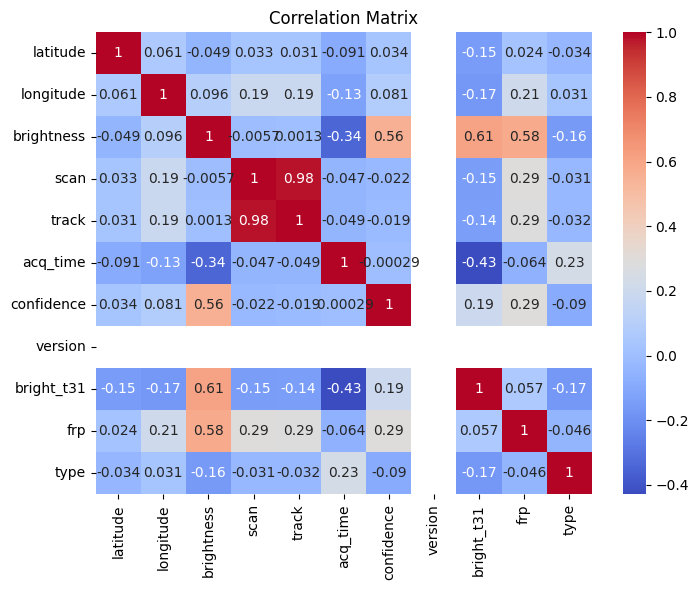

In [10]:
##Correlation Matrix
num_cols = df.select_dtypes(include=np.number).columns.tolist()
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

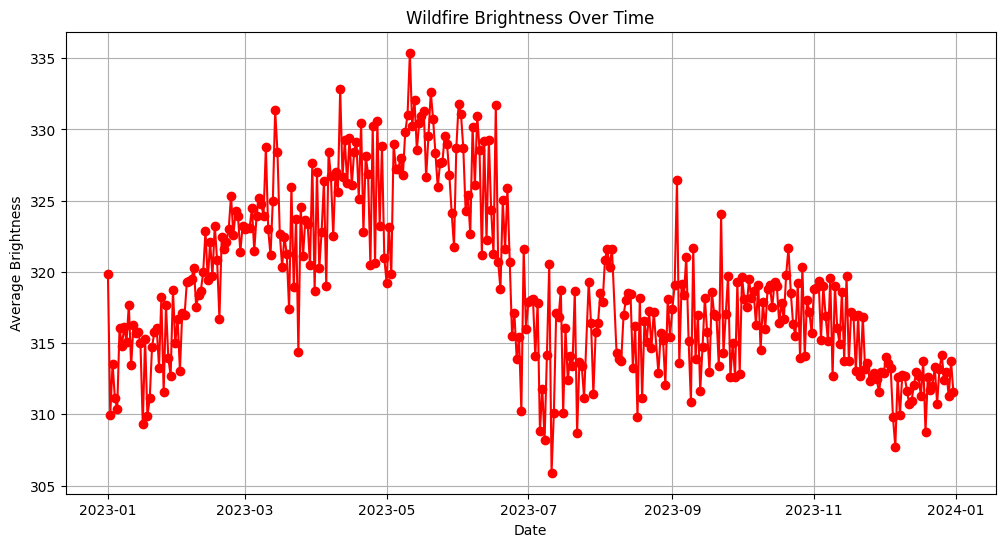

In [11]:

##Time series Analysis
df["acq_date"] = pd.to_datetime(df["acq_date"], errors="coerce")
brightness_trend = df.groupby("acq_date")["brightness"].mean().reset_index()

plt.figure(figsize=(12,6))
plt.plot(brightness_trend["acq_date"], brightness_trend["brightness"], marker="o", linestyle="-", color="red")
plt.title("Wildfire Brightness Over Time")
plt.xlabel("Date")
plt.ylabel("Average Brightness")
plt.grid(True)
plt.show()

In [12]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import numpy as np

In [13]:
if "acq_date" in df.columns:
    df["acq_date"] = pd.to_datetime(df["acq_date"], errors="coerce")
    df["year"] = df["acq_date"].dt.year
    df["month"] = df["acq_date"].dt.month
    df["day"] = df["acq_date"].dt.day
    df = df.drop("acq_date", axis=1)

In [14]:
# Encode categorical columns
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

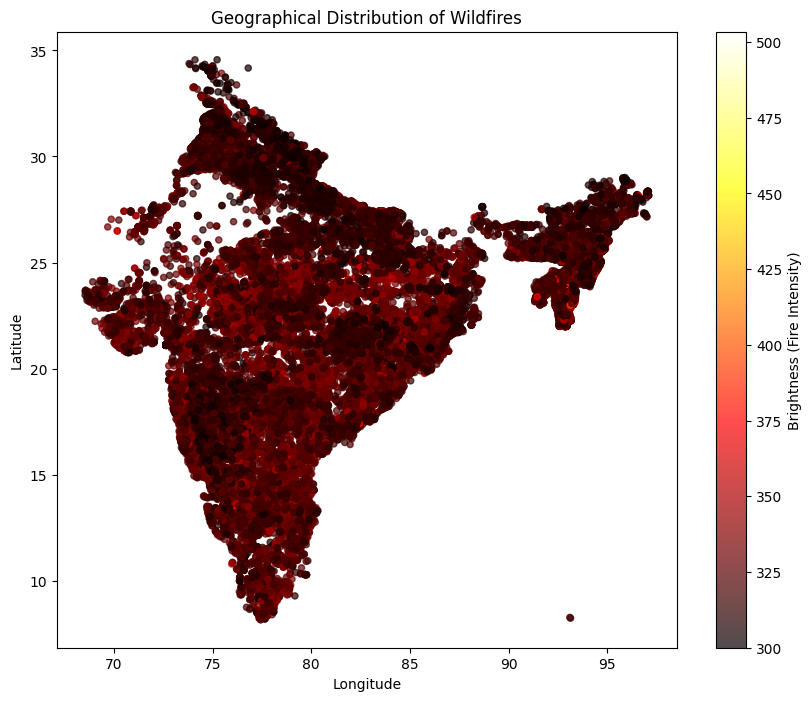

In [15]:
##Geographical Scattered Plot
plt.figure(figsize=(10,8))
scatter = plt.scatter(
    df["longitude"], 
    df["latitude"], 
    c=df["brightness"], 
    cmap="hot", 
    s=20, 
    alpha=0.7
)
plt.colorbar(scatter, label="Brightness (Fire Intensity)")
plt.title("Geographical Distribution of Wildfires")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

In [16]:
##Data Preprocessing
le = LabelEncoder()
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()

for col in categorical_cols:
    df[col] = le.fit_transform(df[col])

In [17]:
##Feature & Target Select
X = df.drop("brightness", axis=1)   
y = df["brightness"]                

In [18]:
##Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.4, random_state=42
)

In [19]:
##Scale Numeric Feature
num_cols = X.select_dtypes(include=np.number).columns.tolist()
scaler = StandardScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [20]:
##Scaler is Saved
joblib.dump(scaler, "wildfire_scaler.pkl")
print("scaler saved as wildfire_scaler.pk1")

scaler saved as wildfire_scaler.pk1


In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [22]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)

In [23]:
rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [24]:
# Save trained model
joblib.dump(rf_model, "wildfire_model.pkl")
print("Model saved as wildfire_model.pkl")

Model saved as wildfire_model.pkl


In [25]:
y_pred = rf_model.predict(X_test)

# Evaluation metrics
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

print("Model Performance:")
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R² Score:", r2)

Model Performance:
Mean Squared Error: 3.7443082839336883
Root Mean Squared Error: 1.935021520276632
R² Score: 0.9777134877520227


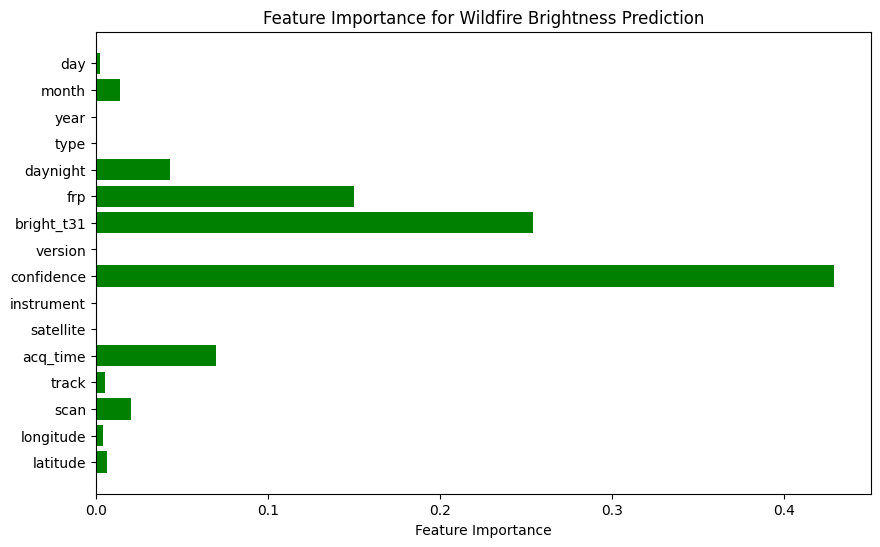

In [26]:
import matplotlib.pyplot as plt

importances = rf_model.feature_importances_
feature_names = X_train.columns

plt.figure(figsize=(10,6))
plt.barh(feature_names, importances, color="green")
plt.xlabel("Feature Importance")
plt.title("Feature Importance for Wildfire Brightness Prediction")
plt.show()

In [27]:
# Save trained model
joblib.dump(rf_model, "wildfire_model.pkl")
print("Model saved as wildfire_model.pkl")

Model saved as wildfire_model.pkl
